### **Approximating $e^x$: Taylor vs Chebyshev vs Remez**

In this notebook, we will explore three different numerical methods for approximating the continuous function $f(x) = e^x$ over the interval $[-1, 1]$. We will start with the standard Taylor Series, improve upon it with Chebyshev Interpolation, and finally find the true Minimax approximation using the Remez Algorithm.

In [140]:
import numpy as np
import matplotlib.pyplot as plt
import math
import ipywidgets as widgets

---
### **1) Taylor Series Approximation**

The Taylor series is the most common way to approximate a function using polynomials. It works by matching the value and the derivatives of the function at a single, specific center point (usually $x=0$, known as a Maclaurin series).

The formula for the Taylor series of $e^x$ centered at $x=0$ is:
$$e^x \approx 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \dots + \frac{x^n}{n!}$$

**The Problem:** Because it is anchored perfectly at $x=0$, the approximation is astoundingly accurate near the center. However, as you move further away towards the edges of the interval ($-1$ or $1$), the error grows significantly.

In [141]:
def taylor_approx_exp(x_eval, N):
	"""
	Approximates e^x using a Taylor series of N terms centered at x=0.
	"""
	approx = np.zeros_like(x_eval, dtype=float)
	for i in range(N):
		approx += (x_eval**i) / math.factorial(i)
	return approx

In [142]:
# Create 100 points between -1 and 1 to test our function
x_plot = np.linspace(-1, 1, 100)

taylor_y = taylor_approx_exp(x_plot, 5)  # 5 terms
true_y = np.exp(x_plot)

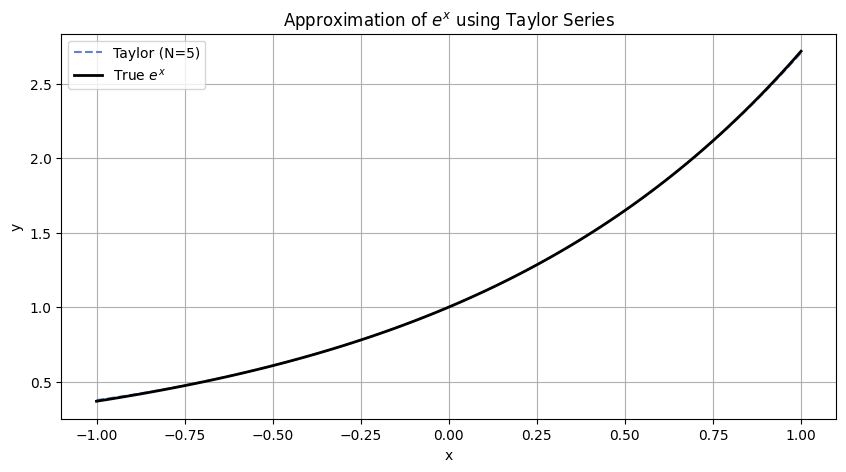

In [143]:
plt.figure(figsize=(10, 5))

plt.plot(x_plot, taylor_y, label="Taylor (N=5)", linestyle="--", color="#5c81d6")
plt.plot(x_plot, true_y, label="True $e^x$", color="black", linewidth=2)

plt.title("Approximation of $e^x$ using Taylor Series")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

---
### **2) Approximating $e^x$ using Chebyshev Polynomials**

**Chebyshev approximations** solve the Taylor edge-error problem by distributing the error evenly across the entire interval, achieving a "near-minimax" approximation. 

Instead of sampling the function at evenly spaced intervals, we sample the function at specific, clustered points called **Chebyshev nodes**. This completely suppresses wild oscillations at the edges (Runge's phenomenon).

#### **The Mathematical Formulas**

**1. The Chebyshev Nodes:** For $k = 0, 1, ..., N-1$, the nodes are calculated as:
$$x_k = \cos\left(\frac{2k + 1}{2N}\pi\right)$$

**2. The Chebyshev Polynomials:** Denoted as $T_j(x)$, defined trigonometrically for $j \ge 0$:
$$T_j(x) = \cos(j \arccos(x))$$

**3. The Chebyshev Coefficients:** 
$$c_j = \frac{2}{N} \sum_{k=0}^{N-1} e^{x_k} T_j(x_k)$$

**4. The Final Approximation:** 
$$e^x \approx p(x) = \frac{c_0}{2} + \sum_{j=1}^{N-1} c_j T_j(x)$$

In [144]:
def chebyshev_approx_exp(x_eval, N):
	"""
	Approximates e^x using a Chebyshev series of N terms.
	"""
	k = np.arange(N)
	nodes = np.cos((2 * k + 1) * np.pi / (2 * N))
	f_nodes = np.exp(nodes)
	
	c = np.zeros(N)
	for j in range(N):
		T_j_nodes = np.cos(j * np.arccos(nodes)) 
		c[j] = (2.0 / N) * np.sum(f_nodes * T_j_nodes)
	
	approximation = np.full_like(x_eval, c[0] / 2.0, dtype=float)
	
	for j in range(1, N):
		T_j_x = np.cos(j * np.arccos(x_eval))
		approximation += c[j] * T_j_x
	
	return approximation

In [145]:
approx_y = chebyshev_approx_exp(x_plot, 5)

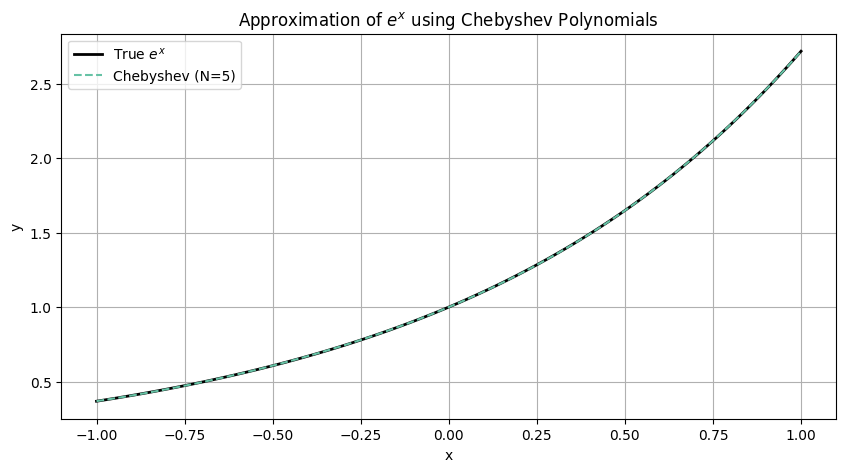

In [146]:
plt.figure(figsize=(10, 5))

plt.plot(x_plot, true_y, label="True $e^x$", color="black", linewidth=2)
plt.plot(x_plot, approx_y, label="Chebyshev (N=5)", linestyle="--", color="#66c2a5")

plt.title("Approximation of $e^x$ using Chebyshev Polynomials")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

---
### **3) Minimax Approximation (The Remez Algorithm)**

While Chebyshev gives us an "almost perfect" distribution of error, the **Remez Algorithm** finds the absolute perfect one. 

It relies on the **Equioscillation Theorem**, which states that for a polynomial to be the true best approximation (minimizing the maximum error), its error curve must oscillate such that all the maximum error peaks and minimum error valleys are exactly equal in magnitude.

Unlike Chebyshev, which is a direct calculation, Remez is an **iterative algorithm**:
1. Start with a good guess (Chebyshev nodes).
2. Solve a system of linear equations to force the error to alternate perfectly ($+E, -E, +E...$) at those points.
3. Scan the interval to find where the *actual* worst errors of this new polynomial are.
4. Shift the nodes to these new peak-error points and repeat the loop until the peaks level out.

In [147]:
def run_remez(degree, iterations=5, verbose=True):
	N = degree
	num_points = N + 2

	k = np.arange(num_points)
	points = np.cos(k * np.pi / (num_points - 1))

	dense_x = np.linspace(-1, 1, 5000)
	true_y = np.exp(dense_x)

	if verbose: print(f"Starting Remez Algorithm for Degree {N}...\n")

	for i in range(iterations):
		# Build linear system: c_0 + c_1*x + ... + (-1)^k * E = f(x)
		A = np.zeros((num_points, num_points))
		b = np.exp(points)
		
		for row in range(num_points):
			x_val = points[row]
			for col in range(N + 1):
				A[row, col] = x_val ** col
			A[row, N + 1] = (-1) ** row
		
		solution = np.linalg.solve(A, b)
		coefficients = solution[:-1]
		calculated_E = solution[-1]
		
		poly_y = np.polyval(coefficients[::-1], dense_x) 
		error_curve = true_y - poly_y
		
		actual_max_error = np.max(np.abs(error_curve))
		if verbose: print(f"Iteration {i+1}: Target E = {abs(calculated_E):.6f}, Actual Max Error = {actual_max_error:.6f}")
		
		# Exchange Step
		new_points = np.zeros(num_points)
		chunk_size = len(dense_x) // num_points
		
		for j in range(num_points):
			start_idx = len(dense_x) - (j + 1) * chunk_size
			end_idx = len(dense_x) - j * chunk_size
			if start_idx < 0: start_idx = 0
			
			chunk_error = error_curve[start_idx:end_idx]
			
			if j % 2 == 0:
				local_ext_idx = np.argmax(chunk_error) 
			else:
				local_ext_idx = np.argmin(chunk_error) 
			
			new_points[j] = dense_x[start_idx + local_ext_idx]
		
		points = new_points

	if verbose: 
		print("\nFinal Coefficients (c_0, c_1, c_2...):")
		print(np.round(coefficients, 5))

	return coefficients

coeffs = run_remez(degree=4, iterations=5)

Starting Remez Algorithm for Degree 4...

Iteration 1: Target E = 0.000543, Actual Max Error = 0.000550
Iteration 2: Target E = 0.000433, Actual Max Error = 0.000769
Iteration 3: Target E = 0.000435, Actual Max Error = 0.000769
Iteration 4: Target E = 0.000435, Actual Max Error = 0.000769
Iteration 5: Target E = 0.000435, Actual Max Error = 0.000769

Final Coefficients (c_0, c_1, c_2...):
[1.00005 0.99769 0.49918 0.17707 0.04385]


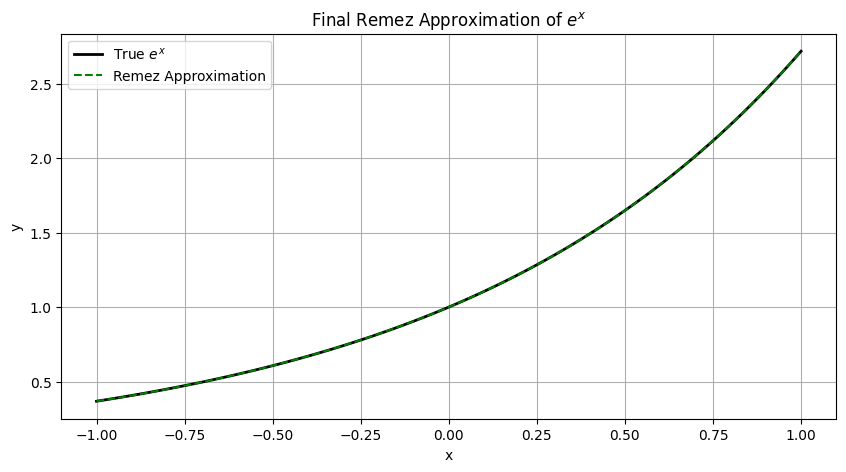

In [148]:
final_approx = np.polyval(coeffs[::-1], x_plot)

plt.figure(figsize=(10, 5))

plt.plot(x_plot, true_y, label="True $e^x$", color="black", linewidth=2)
plt.plot(x_plot, final_approx, label="Remez Approximation", linestyle="--", color="green")

plt.title("Final Remez Approximation of $e^x$")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.show()

---
### **4) Interactive Comparison**

Run the cell below to load an interactive dashboard powered by `ipywidgets`. It brings together all the algorithms we implemented above into a single comparative visualizer.

*(Note: Ensure you have `ipywidgets` installed in your Jupyter environment to use the interactive sliders).* 

**Things to try:**
* Switch the **View Mode** to "Error".
* Hide the Taylor approximation to zoom in on the difference between Chebyshev and Remez.
* Notice how Chebyshev's error peaks are slightly uneven, whereas the Remez (Minimax) error peaks perfectly align along a flat horizontal line—demonstrating the Equioscillation Theorem in action!

In [149]:
def interactive_comparison(N=3, view_mode='Function', show_taylor=True, show_cheb=True, show_remez=True):
	x_plot = np.linspace(-1, 1, 500)
	true_y = np.exp(x_plot)
	
	# Calculate approximations (degree = N-1)
	y_taylor = taylor_approx_exp(x_plot, N)
	y_cheb = chebyshev_approx_exp(x_plot, N)
	coeffs_remez = run_remez(degree=N-1, iterations=5, verbose=False)
	y_remez = np.polyval(coeffs_remez[::-1], x_plot)
	
	plt.figure(figsize=(9, 4))
	
	if view_mode == 'Function':
		plt.plot(x_plot, true_y, label="True $e^x$", color="black", linewidth=2.5)
		if show_taylor: plt.plot(x_plot, y_taylor, label=f"Taylor (N={N})"       , color="#5c81d6", linewidth=2)
		if show_cheb:   plt.plot(x_plot, y_cheb  , label=f"Chebyshev (N={N})"    , color="#66c2a5", linewidth=2)
		if show_remez:  plt.plot(x_plot, y_remez , label=f"Remez/Minimax (N={N})", color="#fc8d62", linewidth=2)
		plt.ylabel("f(x)", fontsize=12)
	else: # Error View
		plt.axhline(0, color='black', linestyle='--', linewidth=1.5)
		if show_taylor: plt.plot(x_plot, true_y - y_taylor, label=f"Taylor Error"       , color="#5c81d6", linewidth=2)
		if show_cheb:   plt.plot(x_plot, true_y - y_cheb  , label=f"Chebyshev Error"    , color="#66c2a5", linewidth=2)
		if show_remez:  plt.plot(x_plot, true_y - y_remez , label=f"Remez/Minimax Error", color="#fc8d62", linewidth=2)
		plt.ylabel("Error (True Value - Approximation)", fontsize=12)
		
		# Dynamically zoom in on Minimax/Chebyshev if Taylor is hidden
		if not show_taylor and (show_cheb or show_remez):
			max_bound = np.max(np.abs(true_y - y_cheb)) * 1.5
			plt.ylim(-max_bound, max_bound)
	
	plt.title(f"Approximation Theory: $e^x$ ({view_mode} View)", fontsize=14)
	plt.xlabel("x", fontsize=12)
	plt.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=11)
	plt.grid(True, alpha=0.3)
	plt.tight_layout()
	plt.show()

In [150]:
# Render the interactive widget
ui = widgets.interact(
	interactive_comparison,
	N=widgets.IntSlider(min=2, max=10, step=1, value=4, description='Terms (N):'),
	view_mode=widgets.RadioButtons(options=['Function', 'Error'], description='Mode:'),
	show_taylor=widgets.Checkbox(value=True, description='Show Taylor'),
	show_cheb  =widgets.Checkbox(value=True, description='Show Chebyshev'),
	show_remez =widgets.Checkbox(value=True, description='Show Remez')
)

interactive(children=(IntSlider(value=4, description='Terms (N):', max=10, min=2), RadioButtons(description='M…